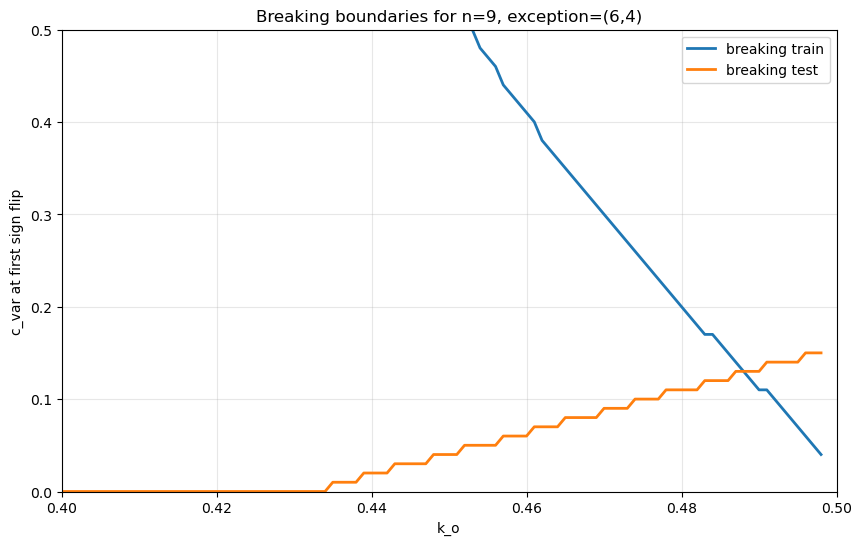

D_jp_til_part_val: 3.8919753086419786
D_jq_til_part_val: 11.961248285322377
D_jp_til_part_val: 5.18930041152264
D_jq_til_part_val: 15.948331047096508
D_jp_til_part_val: 8.216392318244182
D_jq_til_part_val: 25.25152415790281
D_jp_til_part_val: 13.982281664380455
D_jq_til_part_val: 42.97189198801006
D_jp_til_part_val: 24.408931565310215
D_jq_til_part_val: 24.408931565310215
D_jp_til_part_val: 42.97189198801006
D_jq_til_part_val: 13.982281664380455
D_jp_til_part_val: 25.25152415790281
D_jq_til_part_val: 8.216392318244182
D_jp_til_part_val: 15.948331047096508
D_jq_til_part_val: 5.18930041152264
D_jp_til_part_val: 11.961248285322377
D_jq_til_part_val: 3.8919753086419786


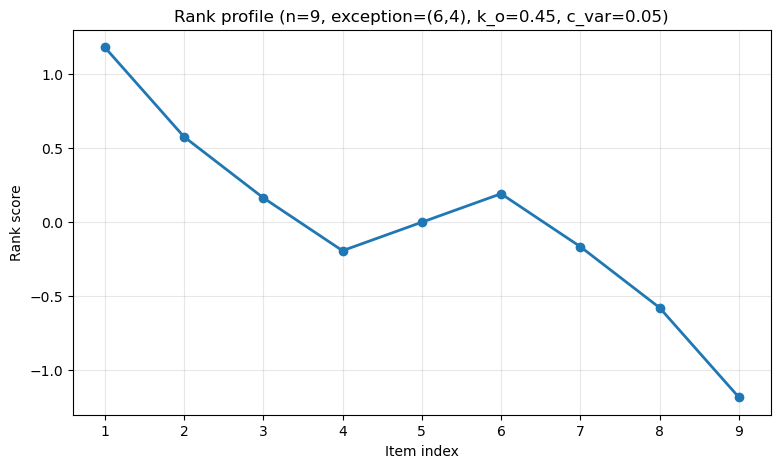

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

# Ensure project root is on path so Ranking_exp imports reliably from this notebook.
project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from Ranking_exp import Ranking_exp

# Parameters: n = 9, exception at (p, q) = (6, 4)
n = 9
p, q = 6, 4
k_s, k_d = 1.0, 0.0

delta_s = k_s - k_d
k_o_vals = np.arange(0.4, 0.499, 0.001)
c_var_vals = np.arange(1e-4, 10, 0.01)
c_vals = 1.0 / (c_var_vals * delta_s)

# Critical pairs used in your original logic
test_pair = (q - 1, p)   # (3, 6)
train_pair = (q, q + 1)  # (4, 5)

breaking_reg_test = []
breaking_reg_train = []

for k_o in k_o_vals:
    # Test boundary: first c_var where margin becomes negative
    test_break = 0.0
    for c_var, c_reg in zip(c_var_vals, c_vals):
        sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d, p=p, q=q, c_reg=c_reg)
        if sim.f_j_k(*test_pair) < 0:
            test_break = c_var
            break
    breaking_reg_test.append(test_break)

    # Train boundary: first c_var where margin becomes negative
    train_break = 0.0
    for c_var, c_reg in zip(c_var_vals, c_vals):
        sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d, p=p, q=q, c_reg=c_reg)
        if sim.f_j_k(*train_pair) < 0:
            train_break = c_var
            break
    breaking_reg_train.append(train_break)

# ---- Plot 1: phase/break diagram ----
plt.figure(figsize=(10, 6))
plt.plot(k_o_vals, breaking_reg_train, label='breaking train', linewidth=2)
plt.plot(k_o_vals, breaking_reg_test, label='breaking test', linewidth=2)
plt.title(f'Breaking boundaries for n={n}, exception=({p},{q})')
plt.xlabel('k_o')
plt.ylabel('c_var at first sign flip')
plt.xlim(0.40, 0.50)
plt.ylim(0, 0.5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ---- Plot 2: ranking profile at one sample (k_o, c_var) ----
k_o_demo = 0.45
c_var_demo = 0.05
c_reg_demo = 1.0 / (c_var_demo * delta_s)

sim_demo = Ranking_exp(n=n, k_o=k_o_demo, k_s=k_s, k_d=k_d, p=p, q=q, c_reg=c_reg_demo)
ranks_demo = sim_demo.calc_rank_analytic()

plt.figure(figsize=(9, 5))
idx = np.arange(1, n + 1)
plt.plot(idx, ranks_demo, marker='o', linewidth=2)
plt.title(f'Rank profile (n={n}, exception=({p},{q}), k_o={k_o_demo}, c_var={c_var_demo})')
plt.xlabel('Item index')
plt.ylabel('Rank score')
plt.xticks(idx)
plt.grid(True, alpha=0.3)
plt.show()